## Figure 6

Note: This notebook requires the following simulation outputs (see `simulations.md` for run commands):

- `out/fig6_fmnist_1l/`: 1 hidden layer, 6 overlap levels x 5 seeds (panels b-j)
- `out/fig6_fmnist_3l/`: 3 hidden layers, 5 seeds (panels b-d)
- `out/fig6_fmnist_bp_1l/`, `out/fig6_fmnist_bp_3l/`: backprop controls (panels d, g)
- `out/fig6_fmnist_fixedhidden_1l/`, `out/fig6_fmnist_fixedhidden_3l/`: fixed-hidden controls (panel d)
- `out/fig6_fmnist_nohl/`: no-hidden-layer control, dashed line in panel g (optional)

Panels h-j re-run the trained networks (best seed per overlap) open-loop on 100 test images, on CPU (a few seconds per network).

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # silences tf.data warnings about the partially read test-set cache

from collections import defaultdict
from pathlib import Path

import numpy as np
import jax.numpy as jnp

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import spiffyplots
from spiffyplots import MultiPanel
from cmcrameri import cm as cmc

mpl.style.use('spiffy')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",})

from bcp.analysis import HydraMultirun, load_legacy_static_analysis

repo_root = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "bcp").is_dir())

#### Directory setup

In [2]:
out_dir = repo_root / "out"
fmnist_path = repo_root / "data" / "fmnist"

fig6_dir = repo_root / "figures" / "fig6"
fig6_dir.mkdir(parents=True, exist_ok=True)

#### Plotting parameters

In [3]:
cm = 1 / 2.54

singlecolwidth = 8.5 * cm
onehalfcolwidth = 11.4 * cm
doublecolwidth = 17.4 * cm

color_1layer = 'black'
color_3layer = '#CD2027'
color_overlap = cmc.cmaps['navia'](0.5)

linewidth = 1.0

### Load runs

In [4]:
def load(name):
    path = out_dir / name
    if not path.is_dir():
        return []
    return sorted(HydraMultirun(path, result_files=['results.json']).runs, key=lambda run: int(run.config.seed))


def overlap_pct(run):
    # current runs store the overlap as a fraction, the published (2025) runs in percent
    vf = run.config.model.vf
    return int(round(100 * vf.overlap)) if 'overlap' in vf else int(vf.perc_overlap)


def stack(runs, key):
    return np.stack([np.asarray(run.results[key], dtype=float) for run in runs])


def best_test_accuracy(runs):
    # test accuracy at the epoch of lowest validation loss
    return np.array([np.asarray(run.results['test_accuracy'])[np.argmin(run.results['valid_loss'])] for run in runs])


bcp_1l = defaultdict(list)
for run in load('fig6_fmnist_1l'):
    bcp_1l[overlap_pct(run)].append(run)
overlaps = sorted(bcp_1l)

controls = {name: load(f'fig6_fmnist_{name}') for name in ['3l', 'bp_1l', 'bp_3l', 'fixedhidden_1l', 'fixedhidden_3l', 'nohl']}
test_acc = {name: best_test_accuracy(runs) for name, runs in controls.items() if runs}
test_acc['1l'] = best_test_accuracy(bcp_1l[0])

if 'nohl' in test_acc:
    NO_HL_TEST_ACC = test_acc['nohl'].mean()
else:
    NO_HL_TEST_ACC = None
    print(f"Warning: {out_dir / 'fig6_fmnist_nohl'} not found, panel g is drawn without the No HL line.")

In [5]:
for o in overlaps:
    acc = best_test_accuracy(bcp_1l[o])
    print(f"1 hidden layer, {o:>2}% overlap | n={len(acc)} | best test acc {np.round(acc, 2)} | mean {acc.mean():.2f} +- {acc.std():.2f}")
for name, acc in test_acc.items():
    print(f"{name:15s} | n={len(acc)} | mean {acc.mean():.2f} +- {acc.std():.2f}")

1 hidden layer,  0% overlap | n=5 | best test acc [88.17 88.3  88.44 88.09 87.75] | mean 88.15 +- 0.23
1 hidden layer,  2% overlap | n=5 | best test acc [88.28 87.83 88.05 87.91 88.3 ] | mean 88.07 +- 0.19
1 hidden layer,  4% overlap | n=5 | best test acc [87.99 88.1  87.62 87.96 88.36] | mean 88.01 +- 0.24
1 hidden layer,  6% overlap | n=5 | best test acc [87.55 88.04 87.71 87.95 87.43] | mean 87.74 +- 0.23
1 hidden layer,  8% overlap | n=5 | best test acc [87.69 87.87 88.03 87.58 87.51] | mean 87.74 +- 0.19
1 hidden layer, 10% overlap | n=5 | best test acc [87.35 87.35 87.46 87.57 87.58] | mean 87.46 +- 0.10
3l              | n=5 | mean 88.54 +- 0.26
bp_1l           | n=5 | mean 88.91 +- 0.16
bp_3l           | n=5 | mean 89.27 +- 0.21
fixedhidden_1l  | n=5 | mean 80.98 +- 0.39
fixedhidden_3l  | n=5 | mean 76.82 +- 0.34
nohl            | n=5 | mean 84.41 +- 0.05
1l              | n=5 | mean 88.15 +- 0.23


### Panels b-d: one vs three hidden layers

Panel d: test accuracy at the epoch of lowest validation loss for BCP, backprop and fixed hidden layers (only the readout trained), each with 1 and 3 hidden layers.

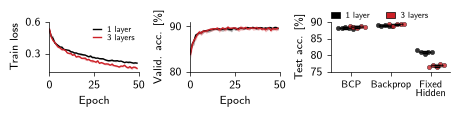

In [6]:
def mean_std(ax, values, color, label=None):
    x = np.arange(values.shape[1])
    ax.plot(x, values.mean(0), color=color, lw=linewidth, label=label)
    ax.fill_between(x, values.mean(0) - values.std(0), values.mean(0) + values.std(0), color=color, alpha=0.3, lw=0)


def epoch_axis(ax):
    ax.set_xlabel('Epoch')
    ax.set_xlim(0, 50)
    ax.set_xticks([0, 25, 50])
    ax.set_xticklabels(['0', '25', '50'])


def loss_axis(ax):
    ax.set_ylabel('Train loss')
    ax.set_yticks([0.3, 0.6])
    ax.set_yticklabels(['0.3', '0.6'])


def accuracy_axis(ax):
    ax.set_ylabel(r'Valid. acc. [\%]')
    ax.set_ylim(80, 91)
    ax.set_yticks([80, 90])
    ax.set_yticklabels(['80', '90'])


fig = MultiPanel(grid=[3], figsize=(onehalfcolwidth, 2.6 * cm), hspace=0.0, wspace=0.0, width_ratios=[3, 3, 4])

for runs, color, label in [(bcp_1l[0], color_1layer, '1 layer'), (controls['3l'], color_3layer, '3 layers')]:
    mean_std(fig.panels[0], stack(runs, 'train_OL_loss'), color, label)
    mean_std(fig.panels[1], stack(runs, 'valid_accuracy'), color)
loss_axis(fig.panels[0])
accuracy_axis(fig.panels[1])
for ax in fig.panels[:2]:
    epoch_axis(ax)
fig.panels[0].legend(loc='upper right', frameon=False, fontsize=6, handlelength=1, handletextpad=0.7, borderpad=0.0, labelspacing=0.1)

# panel d: points per network, box and mean +- SD per condition
ax = fig.panels[2]
groups = [('BCP', '1l', '3l'), ('Backprop', 'bp_1l', 'bp_3l'), ('Fixed\nHidden', 'fixedhidden_1l', 'fixedhidden_3l')]
for pos, (_, name_1l, name_3l) in zip([1, 3, 5], groups):
    for offset, name, color in [(-0.3, name_1l, color_1layer), (0.3, name_3l, color_3layer)]:
        data = test_acc[name]
        ax.boxplot([data], positions=[pos + offset], widths=0.6, patch_artist=True, showfliers=False, showcaps=False,
                   boxprops=dict(facecolor=to_rgba(color, 0.3), edgecolor='black', linewidth=0.35),
                   whiskerprops=dict(linewidth=0.35, color='black'), medianprops=dict(linewidth=0.45, color='black'))
        ax.scatter(np.linspace(pos + offset - 0.375, pos + offset + 0.375, len(data)), data, s=10, color=color,
                   alpha=0.8, edgecolor='black', linewidth=0.3)
        ax.errorbar(pos + offset, data.mean(), yerr=data.std(), fmt='none', ecolor='black', capsize=2, linewidth=0.3)
ax.set_xticks([1, 3, 5])
ax.set_xticklabels([label for label, _, _ in groups], fontsize=7)
ax.set_xlim(0, 6)
ax.set_ylim(75, 90)
ax.set_yticks([75, 80, 85, 90])
ax.set_yticklabels(['75', '80', '85', '90'])
ax.set_ylabel(r'Test acc. [\%]')
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=color, edgecolor='black', linewidth=0.5) for color in [color_1layer, color_3layer]]
ax.legend(handles, ['1 layer', '3 layers'], loc=(0.0, 1.05), frameon=False, fontsize=6, handlelength=1,
          handletextpad=0.7, borderpad=0.0, ncols=2)

plt.savefig(fig6_dir / 'b-d_hidden_layers.pdf', dpi=300, bbox_inches='tight')
plt.show()

### Panels e-g: assembly overlap

One hidden layer. Panel g: crosses are single networks, the line and band mean $\pm$ SD; dashed lines show 1-layer backprop and the no-hidden-layer control.

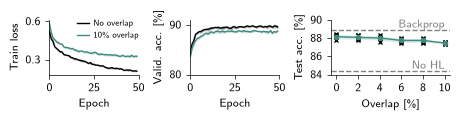

In [7]:
fig = MultiPanel(grid=[3], figsize=(onehalfcolwidth, 2.6 * cm), hspace=0.0, wspace=0.0, width_ratios=[3, 3, 4])

for o, color, label in [(0, 'black', 'No overlap'), (10, color_overlap, r'10\% overlap')]:
    mean_std(fig.panels[0], stack(bcp_1l[o], 'train_OL_loss'), color, label)
    mean_std(fig.panels[1], stack(bcp_1l[o], 'valid_accuracy'), color)
loss_axis(fig.panels[0])
accuracy_axis(fig.panels[1])
for ax in fig.panels[:2]:
    epoch_axis(ax)
fig.panels[0].legend(fontsize=6, loc='upper right', handlelength=1.5, handletextpad=0.5, borderpad=-.5, labelspacing=0.5)

ax = fig.panels[2]
overlap_acc = [best_test_accuracy(bcp_1l[o]) for o in overlaps]
for o, acc in zip(overlaps, overlap_acc):
    ax.plot([o] * len(acc), acc, color='black', marker='x', markersize=3, linestyle='None')
means, stds = np.array([a.mean() for a in overlap_acc]), np.array([a.std() for a in overlap_acc])
ax.plot(overlaps, means, color=color_overlap, marker='o', markersize=3, lw=linewidth)
ax.fill_between(overlaps, means - stds, means + stds, color=color_overlap, alpha=0.2, lw=0)
references = [(test_acc['bp_1l'].mean(), 'Backprop')] + ([(NO_HL_TEST_ACC, 'No HL')] if NO_HL_TEST_ACC else [])
for value, label in references:
    ax.axhline(value, color='gray', ls='--', lw=linewidth)
    ax.annotate(label, xy=(max(overlaps), value), color='gray', ha='right', va='bottom', fontsize=8)
ax.set_xlabel(r'Overlap [\%]')
ax.set_ylabel(r'Test acc. [\%]')
ax.set_xticks(overlaps)
ax.set_xticklabels([str(o) for o in overlaps])
ax.set_ylim(84, 90)
ax.set_yticks([84, 86, 88, 90])
ax.set_yticklabels(['84', '86', '88', '90'])

plt.savefig(fig6_dir / 'e-g_overlap.pdf', bbox_inches='tight')
plt.show()

### Panels h-j: hidden-layer activity after training

All networks are run open-loop on the first 100 test images. Panel h shows the network with the best test accuracy at 0% and 10% overlap, with each neuron's rate normalized to its maximum over the 100 images. Panel i: percentage of excitatory neurons silent for all 100 images, mean $\pm$ SD over the 5 networks. Panel j: lifetime sparseness per neuron (silent neurons count as 0), mean $\pm$ SD over all neurons pooled from the 5 networks.

In [8]:
def hidden_activity(run):
    # the loader migrates configs of the published (2025) runs; current runs load unchanged
    net = load_legacy_static_analysis(run, dataset_path=fmnist_path, dtype=jnp.float32)
    batch = next(iter(net.dataset.get_test_data(net.config.batchsize, flatten=net.model.vf.flatten_input)))
    _, state, _ = net.model.openloop(net.params, net.model.vf.get_initial_state_batchexp(batch[0]), batch[0])
    return np.asarray(net.model.vf.actE(state['vf'][0]['exc']))   # [images, excitatory neurons]


def lifetime_sparseness(rE):
    n = rE.shape[0]
    with np.errstate(divide='ignore', invalid='ignore'):
        sparseness = (1 - rE.mean(0) ** 2 / (rE ** 2).mean(0)) / (1 - 1 / n)
    return np.nan_to_num(sparseness)   # silent neurons -> 0


rE = {o: [hidden_activity(run) for run in bcp_1l[o]] for o in overlaps}   # [overlap][network] -> [images, neurons]
best = {o: int(np.argmax(best_test_accuracy(bcp_1l[o]))) for o in overlaps}

silent = np.array([[100 * np.mean(r.sum(0) == 0) for r in rE[o]] for o in overlaps])   # [overlap, network]
sparseness = {o: [lifetime_sparseness(r) for r in rE[o]] for o in overlaps}
for i, o in enumerate(overlaps):
    print(f"{o:>2}% overlap | silent per network {np.round(silent[i], 1)} | mean {silent[i].mean():.1f} +- {silent[i].std():.1f}"
          f" | sparseness per network {np.round([s.mean() for s in sparseness[o]], 3)}"
          f" | best network: seed {bcp_1l[o][best[o]].config.seed}")

 0% overlap | silent per network [ 8.6 13.3 10.2 14.1 12.5] | mean 11.7 +- 2.0 | sparseness per network [0.849 0.798 0.828 0.79  0.806] | best network: seed 3
 2% overlap | silent per network [30.  37.1 39.4 41.  29. ] | mean 35.3 +- 4.9 | sparseness per network [0.583 0.512 0.504 0.503 0.609] | best network: seed 5
 4% overlap | silent per network [48.6 46.1 49.4 53.3 40.3] | mean 47.5 +- 4.3 | sparseness per network [0.441 0.454 0.43  0.401 0.509] | best network: seed 5
 6% overlap | silent per network [57.  58.  56.7 61.2 51.9] | mean 56.9 +- 3.0 | sparseness per network [0.362 0.353 0.371 0.329 0.418] | best network: seed 2
 8% overlap | silent per network [64.1 62.5 58.6 68.5 63.9] | mean 63.5 +- 3.2 | sparseness per network [0.307 0.319 0.358 0.271 0.309] | best network: seed 3
10% overlap | silent per network [70.1 66.7 71.2 68.8 66.8] | mean 68.7 +- 1.8 | sparseness per network [0.258 0.287 0.243 0.273 0.282] | best network: seed 5


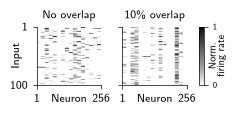

In [16]:
NB_IMAGES, NB_NEURONS = 100, 256
cmap_activity = cmc.cmaps['grayC_r']

fig = MultiPanel(grid=[2], figsize=(5.7 * cm, 2.6 * cm), hspace=0.0, wspace=0.0)
for ax, o, title in [(fig.panels[0], 0, 'No overlap'), (fig.panels[1], 10, r'10\% overlap')]:
    rates = rE[o][best[o]][:NB_IMAGES, :NB_NEURONS]
    with np.errstate(divide='ignore', invalid='ignore'):
        rates = np.nan_to_num(rates / rates.max(0, keepdims=True))   # normalized per neuron; silent neurons -> 0
    ax.imshow(rates, cmap=cmap_activity, aspect='auto', vmin=0, vmax=1)
    ax.set_title(title, fontsize=8)
    ax.set_xlabel('Neuron', fontsize=8, labelpad=-7)
    ax.set_xticks([0, NB_NEURONS - 1])
    ax.set_xticklabels([1, NB_NEURONS])
    ax.set_yticks([-0.5, NB_IMAGES - 0.5])
    ax.set_yticklabels([1, NB_IMAGES] if o == 0 else [])
fig.panels[0].set_ylabel('Input', fontsize=8, labelpad=-8)
colorbar = plt.colorbar(mpl.cm.ScalarMappable(cmap=cmap_activity), ax=fig.panels[1], pad=0.05, aspect=12)
colorbar.set_ticks([0, 1])
colorbar.set_ticklabels(['0', '1'], fontsize=6)
colorbar.set_label('Norm.\nfiring rate', fontsize=7, labelpad=-6)

plt.savefig(fig6_dir / 'h_activity.pdf', bbox_inches='tight')
plt.show()

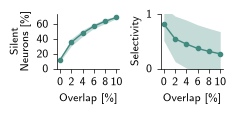

selectivity: {0: np.float32(0.814), 2: np.float32(0.542), 4: np.float32(0.447), 6: np.float32(0.367), 8: np.float32(0.313), 10: np.float32(0.269)} SD {0: np.float32(0.305), 2: np.float32(0.416), 4: np.float32(0.439), 6: np.float32(0.432), 8: np.float32(0.421), 10: np.float32(0.406)}


In [10]:
# selectivity: all neurons of the 5 networks pooled
selectivity = np.array([np.concatenate(sparseness[o]).mean() for o in overlaps])
selectivity_sd = np.array([np.concatenate(sparseness[o]).std() for o in overlaps])

fig = MultiPanel(grid=[2], figsize=(5.7 * cm, 2.6 * cm), hspace=0.0, wspace=0.0)
for ax, values, sd, ylabel, yticks in [(fig.panels[0], silent.mean(1), silent.std(1), 'Silent\nNeurons [\\%]', [0, 20, 40, 60]),
                                        (fig.panels[1], selectivity, selectivity_sd, 'Selectivity', [0, 1])]:
    ax.plot(overlaps, values, color=color_overlap, marker='o', markersize=3, lw=linewidth)
    ax.fill_between(overlaps, values - sd, values + sd, color=color_overlap, alpha=0.3, lw=0)
    ax.set_xlabel(r'Overlap [\%]')
    ax.set_ylabel(ylabel)
    ax.set_xticks(overlaps)
    ax.set_xticklabels([str(o) for o in overlaps])
    ax.set_yticks(yticks)
    ax.set_yticklabels([str(t) for t in yticks])
fig.panels[1].set_ylim(0, 1)

plt.savefig(fig6_dir / 'i-j_silent_selectivity.pdf', bbox_inches='tight')
plt.show()
print('selectivity:', dict(zip(overlaps, np.round(selectivity, 3))), 'SD', dict(zip(overlaps, np.round(selectivity_sd, 3))))